Possíveis análises:

- neighborhood x price
- OverallQual (avaliação do material geral e acabamento da casa) x Price
- OverallCond (avaliação do estado geral da casa) x Price
- YearBuilt (data de construção) e YearRemodAdd (Data de reforma) --> usar YearRemodAdd (se não houve reformas, é o msm de construção)
- histograma de Heating (tipo de aquecimento)?
- GrLivArea (area habitavel acima do solo em pés quadrados)
- BedroomAbvGr (quartos acima do chão)
- MSZoning (classificação geral de zoneamento da venda)
- Street (tipo de acesso rodoviario) e Alley (tipo de acesso à prioridade)
- HouseStyle
- ExterQual e ExterCond
- BsmtQual (qualidade do porão) --> avaliar se número de casas com porão é significativo o bastante
- TotalBsmtSF (total de pés quadrados da área do porão)
- Fireplace ?

In [ ]:
import pandas as pd

houses = pd.read_csv('houses.csv')
houses.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


`Neighborhood`: Locais físicos dentro dos limites da cidade de Ames

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker

In [ ]:
# Check missing values in Neighborhood before plotting
missing_neighborhood = houses['Neighborhood'].isna().sum()
print(f'Missing values in Neighborhood: {missing_neighborhood}')

houses['Neighborhood'].value_counts(dropna=False)

Missing values in Neighborhood: 0


Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

/tmp/ipykernel_139175/651630342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')


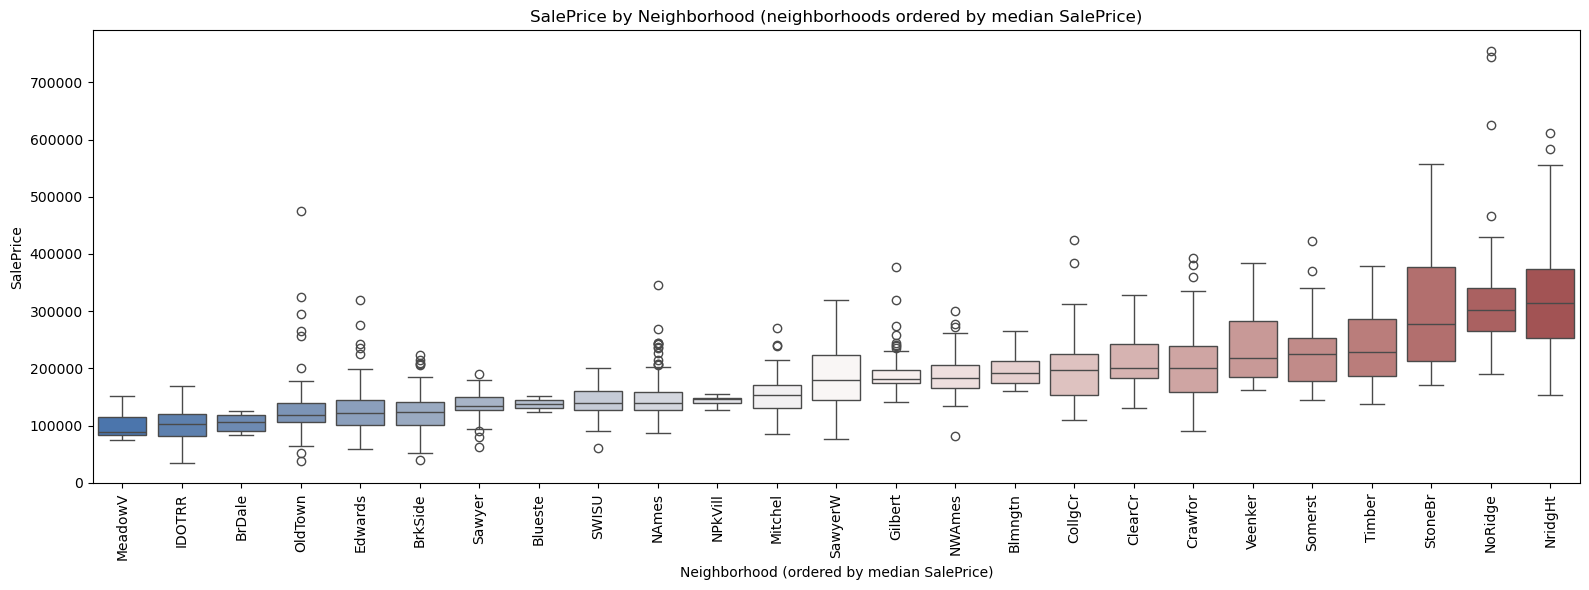

In [ ]:
# Boxplot of SalePrice by Neighborhood ordered by median SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

# compute neighborhood medians and order neighborhoods from smallest to largest median
neigh_medians = houses.groupby('Neighborhood')['SalePrice'].median().sort_values()
order = neigh_medians.index

plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood (neighborhoods ordered by median SalePrice)')
plt.xlabel('Neighborhood (ordered by median SalePrice)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

O que fazer com bairros que possuem poucas instâncias??
- Agrupar num grupo "Outros"? --> usar mediana??

Bairros com menos de 30 instâncias
- ``Blueste``
- ``NPkVill``
- ``Veenker``
- ``BrDale``
- ``MeadowV``
- ``Blmngtn``
- ``StoneBr``
- ``SWISU``
- ``ClearCr``

In [ ]:
# 1) Check missing values and basic stats for GrLivArea
missing_grliv = houses['GrLivArea'].isna().sum()
print(f"Missing values in GrLivArea: {missing_grliv}")

# Show summary statistics to get a sense of distribution and outliers
houses['GrLivArea'].describe()


Missing values in GrLivArea: 0


count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

Pearson correlation: 0.709
Spearman correlation: 0.731
Kendall correlation: 0.544


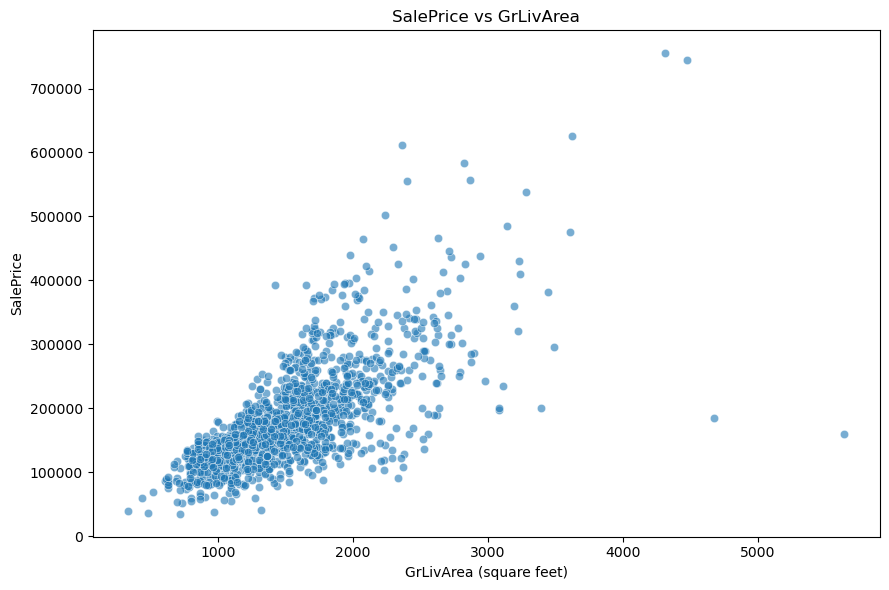

In [ ]:
# 2) Scatter plot (GrLivArea vs SalePrice) with correlation and trendline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

# compute Pearson, Spearman, and Kendall correlations
pearson_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='pearson')
spearman_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='spearman')
kendall_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='kendall')

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Kendall correlation: {kendall_corr:.3f}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=houses, x='GrLivArea', y='SalePrice', alpha=0.6)
plt.title('SalePrice vs GrLivArea')
plt.xlabel('GrLivArea (square feet)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

In [ ]:
# Check missing values for categorical variables
variables = ['Heating', 'BedroomAbvGr', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtQual', 'Fireplaces']

missing_info = {}
for var in variables:
    missing_count = houses[var].isna().sum()
    missing_info[var] = missing_count
    print(f"{var}: {missing_count} missing values")

print("\nSummary:")
import pandas as pd
missing_df = pd.DataFrame(list(missing_info.items()), columns=['Variable', 'Missing Count'])
print(missing_df)


Heating: 0 missing values
BedroomAbvGr: 0 missing values
MSZoning: 0 missing values
Street: 0 missing values
Alley: 1369 missing values
HouseStyle: 0 missing values
BsmtQual: 37 missing values
Fireplaces: 0 missing values

Summary:
       Variable  Missing Count
0       Heating              0
1  BedroomAbvGr              0
2      MSZoning              0
3        Street              0
4         Alley           1369
5    HouseStyle              0
6      BsmtQual             37
7    Fireplaces              0


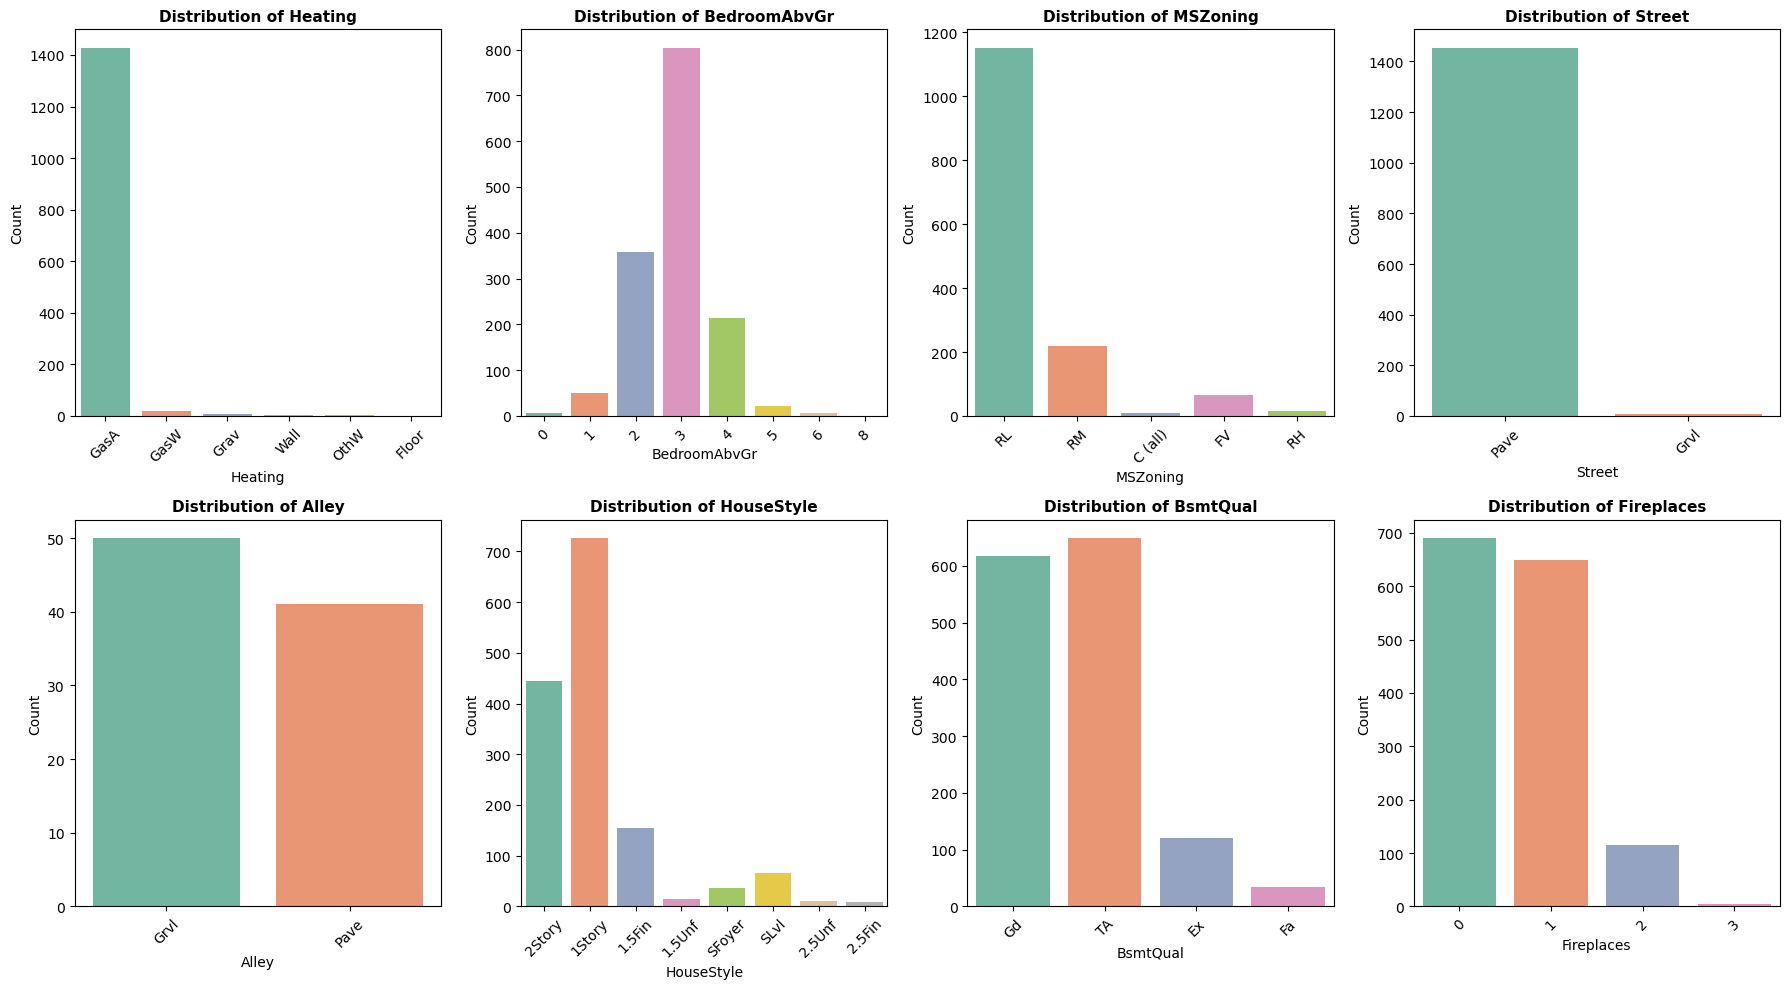

In [ ]:
# Create histograms (countplots) for each categorical variable
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Heating', 'BedroomAbvGr', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtQual', 'Fireplaces']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    sns.countplot(data=houses, x=var, ax=axes[idx], palette='Set2', hue=var, legend=False)
    axes[idx].set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
